# Notebook 3: Model Validation and Optimization

## Objective

In Notebook 2, we trained two baseline models:

- Logistic Regression
- Random Forest Classifier

Random Forest performed better on the test dataset.

However, one train-test split is not enough to confidently select a production-ready model.

In this notebook, we will:

1. Validate models using 5-Fold Cross-Validation
2. Evaluate test performance using multiple metrics
3. Analyze confusion matrices
4. Analyze ROC-AUC curves
5. Tune model hyperparameters
6. Compare baseline and tuned models
7. Select the final production-ready model
8. Save the final pipeline for the next MLflow notebook

In [493]:
# Data manipulation libraries
import pandas as pd
import numpy as np

# Visualization libraries
import matplotlib.pyplot as plt
import seaborn as sns

# Train-test split and model validation
from sklearn.model_selection import train_test_split, cross_validate, GridSearchCV

# Preprocessing and pipeline tools
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

# Machine learning models
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

# Evaluation metrics
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    RocCurveDisplay,
    classification_report
)

# Save final model
import joblib

In [494]:
#Load Dataset
df = pd.read_csv("../data/processed/heart_cleaned.csv")

df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,1,145,233,1,2,150,0,2.3,3,0.0,6.0,0
1,67,1,4,160,286,0,2,108,1,1.5,2,3.0,3.0,1
2,67,1,4,120,229,0,2,129,1,2.6,2,2.0,7.0,1
3,37,1,3,130,250,0,0,187,0,3.5,3,0.0,3.0,0
4,41,0,2,130,204,0,2,172,0,1.4,1,0.0,3.0,0


In [495]:
df.shape

(303, 14)

In [496]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    int64  
 1   sex       303 non-null    int64  
 2   cp        303 non-null    int64  
 3   trestbps  303 non-null    int64  
 4   chol      303 non-null    int64  
 5   fbs       303 non-null    int64  
 6   restecg   303 non-null    int64  
 7   thalach   303 non-null    int64  
 8   exang     303 non-null    int64  
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    int64  
 11  ca        303 non-null    float64
 12  thal      303 non-null    float64
 13  target    303 non-null    int64  
dtypes: float64(3), int64(11)
memory usage: 33.3 KB


In [497]:
#Seperate Feature and Target
X = df.drop("target", axis=1)
y = df["target"]

# Display the shapes of features and target
print("Features shape:", X.shape)
print("Target shape:", y.shape)

Features shape: (303, 13)
Target shape: (303,)


In [498]:
#Test Train Split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training features:", X_train.shape)
print("Testing features:", X_test.shape)
print("Training target:", y_train.shape)
print("Testing target:", y_test.shape)

Training features: (242, 13)
Testing features: (61, 13)
Training target: (242,)
Testing target: (61,)


In [499]:
#Define Feature Group
numerical_features = [
    "age",
    "trestbps",
    "chol",
    "thalach",
    "oldpeak"
]

categorical_features = [
    "sex",
    "cp",
    "fbs",
    "restecg",
    "exang",
    "slope",
    "ca",
    "thal"
]

print("Numerical Features:", numerical_features)
print("Categorical Features:", categorical_features)

Numerical Features: ['age', 'trestbps', 'chol', 'thalach', 'oldpeak']
Categorical Features: ['sex', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'ca', 'thal']


In [500]:
#Preprocessing Pipeline
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numerical_features),
        ("cat", "passthrough", categorical_features)
    ]
)

In [501]:
#Base line model pipeline
# Create Logistic Regression pipeline
logistic_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", LogisticRegression(max_iter=1000, random_state=42))
    ]
)

# Create Random Forest pipeline
random_forest_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", RandomForestClassifier(random_state=42))
    ]
)

## Step 1.1 : Validate Baseline Models using 5-Fold Cross-Validation

In Notebook 2, the models were evaluated using a single train-test split.

Although this provides an initial estimate of model performance, the result may vary depending on how the data is divided.

To obtain a more reliable estimate, we use **5-Fold Cross-Validation**.

In 5-Fold Cross-Validation:

- The training data is divided into five equal parts (folds).
- The model is trained five times.
- Each fold is used once as the validation set.
- The evaluation metrics are averaged across all five folds.

This provides a more stable estimate of how well the model is expected to generalize to unseen data.

## 1.2 Define Evaluation Matrix

In [502]:
# Define evaluation metrics for Cross-Validation

scoring_metrics = [
    "accuracy",
    "precision",
    "recall",
    "f1",
    "roc_auc"
]

## 1.3 Perform 5 Fold Cross Validation

In [503]:
# Perform 5-Fold Cross-Validation for Logistic Regression

logistic_cv_results = cross_validate(
    estimator=logistic_pipeline,
    X=X_train,
    y=y_train,
    cv=5,
    scoring=scoring_metrics
)

# Perform 5-Fold Cross-Validation for Random Forest

random_forest_cv_results = cross_validate(
    estimator=random_forest_pipeline,
    X=X_train,
    y=y_train,
    cv=5,
    scoring=scoring_metrics
)

## 2.1 Inspect the cross validation results

In [504]:
# Check the type of object returned by cross_validate()

type(logistic_cv_results) 
# The Output of the command is A "Dictionary" it stores information as a key-value pairs
# cross_validate() stores different metrics using different keys

dict

In [505]:
# Display all the keys returned by cross_validate()

logistic_cv_results.keys()

dict_keys(['fit_time', 'score_time', 'test_accuracy', 'test_precision', 'test_recall', 'test_f1', 'test_roc_auc'])

 - test_accuracy: Stores the accuracy from each of the five folds.
 - test_precision: Stores the precision from each fold
 - test_recall: Stores the recall from each fold.
 - test_f1: Stores the F1-score from each fold.
 - test_roc_auc: Stores the ROC-AUC score from each fold.
 - fit_time: How long the model took to train in each fold.
 - score_time: How long the model took to calculate the evaluation metrics.


In [506]:
# Display Accuracy obtained in each fold

logistic_cv_results["test_accuracy"]

array([0.91836735, 0.7755102 , 0.83333333, 0.83333333, 0.79166667])

In [507]:
# Calculate average Cross-Validation Accuracy

logistic_cv_results["test_accuracy"].mean()

np.float64(0.8304421768707483)

## 2.2 Comparision Table
 - Instead of checking one metric at a time for each model,create a professional comparison table.

Summarize Cross-Validation Results

The `cross_validate()` function returns several evaluation metrics for each fold.

To compare models easily, we will calculate the average value of each metric and organize the results into a summary table.

In [508]:
#Cross Validation summery
def summarize_cv_results(cv_results, model_name):
    """
    Calculate the average Cross-Validation metrics for a model.
    """
    
    return {
        "Model": model_name,
        "CV Accuracy": cv_results["test_accuracy"].mean(),
        "CV Precision": cv_results["test_precision"].mean(),
        "CV Recall": cv_results["test_recall"].mean(),
        "CV F1 Score": cv_results["test_f1"].mean(),
        "CV ROC-AUC": cv_results["test_roc_auc"].mean()
    }


cv_results_df = pd.DataFrame([
    summarize_cv_results(
        logistic_cv_results,
        "Logistic Regression"
    ),
    summarize_cv_results(
        random_forest_cv_results,
        "Random Forest"
    )
])

cv_results_df

,Model,CV Accuracy,CV Precision,CV Recall,CV F1 Score,CV ROC-AUC
0,Logistic Regression,0.830442,0.846320,0.774308,0.807062,0.888390
1,Random Forest,0.805442,0.824945,0.728458,0.772703,0.890954


In [509]:
#Train Base line model
logistic_pipeline.fit(X_train, y_train)
random_forest_pipeline.fit(X_train, y_train)

print("Baseline models trained successfully.")

Baseline models trained successfully.


In [510]:
# Class predictions

logistic_predictions = logistic_pipeline.predict(X_test)

random_forest_predictions = random_forest_pipeline.predict(X_test)

# Probability predictions

logistic_probabilities = logistic_pipeline.predict_proba(X_test)[:, 1]

random_forest_probabilities = random_forest_pipeline.predict_proba(X_test)[:, 1]


## 2.3 : Evaluate the Baseline Models

Now that predictions have been generated, we evaluate the performance of each model on the unseen test dataset.

To avoid repeating the same code for multiple models, we create a reusable evaluation function.

The function calculates:

- Accuracy
- Precision
- Recall
- F1 Score
- ROC-AUC

These metrics together provide a comprehensive understanding of model performance.

In [511]:
# Function to evaluate a classification model

def evaluate_model(model_name, y_true, y_pred, y_prob):
    """
    Calculate evaluation metrics for a classification model.
    """

    results = {
        "Model": model_name,
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred),
        "Recall": recall_score(y_true, y_pred),
        "F1 Score": f1_score(y_true, y_pred),
        "ROC-AUC": roc_auc_score(y_true, y_prob)
    }

    return results

In [512]:
logistic_results = evaluate_model(
    model_name="Logistic Regression",
    y_true=y_test,
    y_pred=logistic_predictions,
    y_prob=logistic_probabilities
)

In [513]:
random_forest_results = evaluate_model(
    model_name="Random Forest",
    y_true=y_test,
    y_pred=random_forest_predictions,
    y_prob=random_forest_probabilities
)

In [514]:
baseline_results_df = pd.DataFrame([
    logistic_results,
    random_forest_results
])

baseline_results_df

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression,0.868852,0.812500,0.928571,0.866667,0.951299
1,Random Forest,0.918033,0.870968,0.964286,0.915254,0.954004


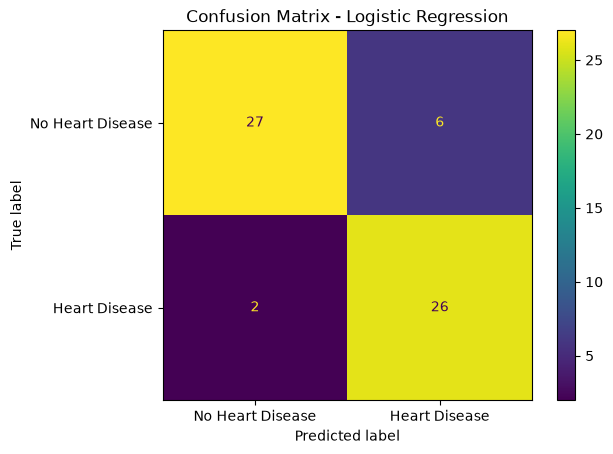

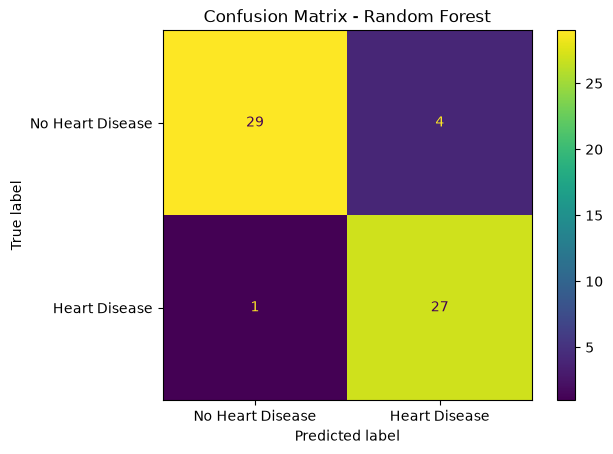

In [515]:
#Confusion matrix
for model_name, model in [
    ("Logistic Regression", logistic_pipeline),
    ("Random Forest", random_forest_pipeline)
]:
    y_pred = model.predict(X_test)

    cm = confusion_matrix(y_test, y_pred)

    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=["No Heart Disease", "Heart Disease"]
    )

    disp.plot()
    plt.title(f"Confusion Matrix - {model_name}")
    plt.show()

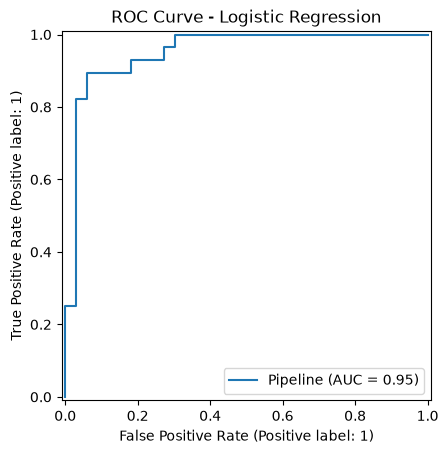

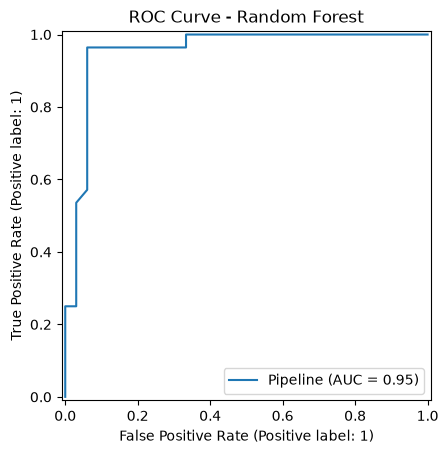

In [516]:
#ROC curve
for model_name, model in [
    ("Logistic Regression", logistic_pipeline),
    ("Random Forest", random_forest_pipeline)
]:
    RocCurveDisplay.from_estimator(
        model,
        X_test,
        y_test
    )
    plt.title(f"ROC Curve - {model_name}")
    plt.show()

In [517]:
#Hyper parameter tuning Logistic regression
logistic_param_grid = {
    "model__C": [0.01, 0.1, 1, 10, 100],
    "model__solver": ["liblinear", "lbfgs"]
}

logistic_grid_search = GridSearchCV(
    estimator=logistic_pipeline,
    param_grid=logistic_param_grid,
    cv=5,
    scoring="roc_auc",
    n_jobs=-1
)

logistic_grid_search.fit(X_train, y_train)

print("Best Logistic Regression Parameters:")
print(logistic_grid_search.best_params_)

print("\nBest Logistic Regression CV ROC-AUC:")
print(logistic_grid_search.best_score_)

Best Logistic Regression Parameters:
{'model__C': 10, 'model__solver': 'lbfgs'}

Best Logistic Regression CV ROC-AUC:
0.889676024458633


In [518]:
# Extract the best Logistic Regression pipeline

best_logistic_model = logistic_grid_search.best_estimator_

print("Best Logistic Regression model extracted successfully.")

Best Logistic Regression model extracted successfully.


In [519]:
#Random Forest Hyperparameter tuning
random_forest_param_grid = {
    "model__n_estimators": [100, 200, 300],
    "model__max_depth": [None, 5, 10, 15],
    "model__min_samples_split": [2, 5, 10],
    "model__min_samples_leaf": [1, 2, 4]
}

random_forest_grid_search = GridSearchCV(
    estimator=random_forest_pipeline,
    param_grid=random_forest_param_grid,
    cv=5,
    scoring="roc_auc",
    n_jobs=-1
)

random_forest_grid_search.fit(X_train, y_train)

print("Best Random Forest Parameters:")
print(random_forest_grid_search.best_params_)

print("\nBest Random Forest CV ROC-AUC:")
print(random_forest_grid_search.best_score_)

Best Random Forest Parameters:
{'model__max_depth': 5, 'model__min_samples_leaf': 1, 'model__min_samples_split': 5, 'model__n_estimators': 300}

Best Random Forest CV ROC-AUC:
0.8954095019312411


In [520]:
# Extract the best Random Forest pipeline

best_random_forest_model = random_forest_grid_search.best_estimator_

print("Best Random Forest model extracted successfully.")

Best Random Forest model extracted successfully.


In [521]:
# Generate predictions using the tuned Logistic Regression model

best_logistic_predictions = best_logistic_model.predict(X_test)

best_logistic_probabilities = (
    best_logistic_model.predict_proba(X_test)[:, 1]
)

# Generate predictions using the tuned Random Forest model

best_random_forest_predictions = (
    best_random_forest_model.predict(X_test)
)

best_random_forest_probabilities = (
    best_random_forest_model.predict_proba(X_test)[:, 1]
)

In [522]:
tuned_results_df = pd.DataFrame([
    evaluate_model(
        "Logistic Regression Tuned",
        y_test,
        best_logistic_predictions,
        best_logistic_probabilities
    ),

    evaluate_model(
        "Random Forest Tuned",
        y_test,
        best_random_forest_predictions,
        best_random_forest_probabilities
    )
])

tuned_results_df

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression Tuned,0.868852,0.812500,0.928571,0.866667,0.949134
1,Random Forest Tuned,0.901639,0.866667,0.928571,0.896552,0.959957


In [523]:
#Compair All model
final_comparison_df = pd.concat(
    [baseline_results_df, tuned_results_df],
    ignore_index=True
)

final_comparison_df.sort_values(by="ROC-AUC", ascending=False)

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
3,Random Forest Tuned,0.901639,0.866667,0.928571,0.896552,0.959957
1,Random Forest,0.918033,0.870968,0.964286,0.915254,0.954004
0,Logistic Regression,0.868852,0.812500,0.928571,0.866667,0.951299
2,Logistic Regression Tuned,0.868852,0.812500,0.928571,0.866667,0.949134


In [524]:
#Select Final Model
print("=" * 60)
print("FINAL MODEL SELECTION")
print("=" * 60)

print("Selected Model : Tuned Random Forest")
print("Reason         : Highest ROC-AUC after hyperparameter tuning")
print("Deployment     : This pipeline will be used in Notebook 4 (MLflow)")

FINAL MODEL SELECTION
Selected Model : Tuned Random Forest
Reason         : Highest ROC-AUC after hyperparameter tuning
Deployment     : This pipeline will be used in Notebook 4 (MLflow)


In [525]:
#Save Final Model Pipeline
final_model = best_random_forest_model

print("Final production-ready model selected.")

joblib.dump(final_model, "../models/final_random_forest_pipeline.pkl")

print("Final model pipeline saved successfully.")

Final production-ready model selected.
Final model pipeline saved successfully.


# Conclusion

In this notebook, we validated and optimized the baseline machine learning models developed in Notebook 2.

The main tasks completed were:

- Validated the baseline models using 5-Fold Cross-Validation.
- Evaluated the models using Accuracy, Precision, Recall, F1-score, and ROC-AUC.
- Analyzed model performance using Confusion Matrices and ROC Curves.
- Performed Hyperparameter Tuning using GridSearchCV.
- Compared the baseline and tuned models.
- Selected the Tuned Random Forest model as the final production-ready model.

The selected pipeline has been saved and will be tracked using MLflow in the next notebook.